In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy import signal 
import warnings 

warnings.filterwarnings("ignore") 
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['axes.grid'] = True
 

In [3]:
df=pd.read_csv('../signal_processing/IQ Raw Data of Continuous Wave Radar 24 GHz ViRa Sykno.csv')
df.head()

,# Created with Sykno's ViRa24,UI version 1.0,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,# Start time: 2025-05-23 09-54-56,NaN,NaN,NaN,NaN,NaN
1,# Format: I,Q,ECG1,ECG2,ANA1,ANA2
2,# Sample rate: 1000 Sa/s,NaN,NaN,NaN,NaN,NaN
3,-117974,-1424541,2162,2045,-29066,-33862
4,-117955,-1424235,2148,2042,-29067,-33861


In [5]:
df.shape

(60009, 6)

In [7]:
df.describe()

,# Created with Sykno's ViRa24,UI version 1.0,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
count,60009,60007,60007,60007,60007,60007
unique,54296,54449,69,66,193,195
top,-57266,-1263530,2148,2038,-29074,-33859
freq,5,6,3562,3638,1040,1022


In [8]:
df.isnull().sum()

# Created with Sykno's ViRa24    0
 UI version 1.0                  2
Unnamed: 2                       2
Unnamed: 3                       2
Unnamed: 4                       2
Unnamed: 5                       2
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
fs = 1000  # Sampling frequency
N=len(df)  # Number of samples 
duration = N/fs  # Duration in seconds 

print(f"Number of samples: {N}") 
print(f"Duration: {duration} seconds") 
print(f"Sampling frequency: {fs} Hz") 
print(f"Time between samples: {1/fs} seconds") 
print(f"Total duration: {N/fs} seconds") 


Number of samples: 60009
Duration: 60.009 seconds
Sampling frequency: 1000 Hz
Time between samples: 0.001 seconds
Total duration: 60.009 seconds


In [13]:
time= np.arange(len(df))/fs  # Time vector 
df['time'] = time  # Add time column to dataframe 
df

,# Created with Sykno's ViRa24,UI version 1.0,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,time
0,# Start time: 2025-05-23 09-54-56,NaN,NaN,NaN,NaN,NaN,0.000
1,# Format: I,Q,ECG1,ECG2,ANA1,ANA2,0.001
2,# Sample rate: 1000 Sa/s,NaN,NaN,NaN,NaN,NaN,0.002
3,-117974,-1424541,2162,2045,-29066,-33862,0.003
4,-117955,-1424235,2148,2042,-29067,-33861,0.004
...,...,...,...,...,...,...,...
60004,-132227,-1403638,2143,2039,-29151,-33906,60.004
60005,-131901,-1404240,2138,2054,-29146,-33894,60.005
60006,-131508,-1404821,2131,2035,-29139,-33899,60.006
60007,-131064,-1405304,2127,2019,-29144,-33897,60.007


In [17]:
# ----------------------------------------------------------------------
# Load the raw ViRa‑24 GHz CSV file
# ----------------------------------------------------------------------
# The file starts with several comment lines (starting with '#').  
# We skip those, tell pandas that there is **no header row**, and supply the
# column names ourselves.
csv_path = '../signal_processing/IQ Raw Data of Continuous Wave Radar 24 GHz ViRa Sykno.csv'

col_names = ['I', 'Q', 'ECG1', 'ECG2', 'ANA1', 'ANA2']
df = pd.read_csv(csv_path,
                 comment='#',      # ignore lines that begin with '#'
                 header=None,      # the file has no header line after the comments
                 names=col_names)  # assign the column names manually

# ----------------------------------------------------------------------
# Add a time column (the file header says “Sample rate: 1000 Sa/s”)
# ----------------------------------------------------------------------
sample_rate = 1000                     # samples per second
df['time'] = np.arange(len(df)) / sample_rate

# ----------------------------------------------------------------------
# Quick sanity check – show the first few rows
# ----------------------------------------------------------------------
df.head()

,I,Q,ECG1,ECG2,ANA1,ANA2,time
0,-117974,-1424541,2162,2045,-29066,-33862,0.000
1,-117955,-1424235,2148,2042,-29067,-33861,0.001
2,-117995,-1423936,2143,2040,-29067,-33857,0.002
3,-118173,-1423894,2149,2049,-29061,-33846,0.003
4,-118412,-1423963,2148,2063,-29064,-33845,0.004


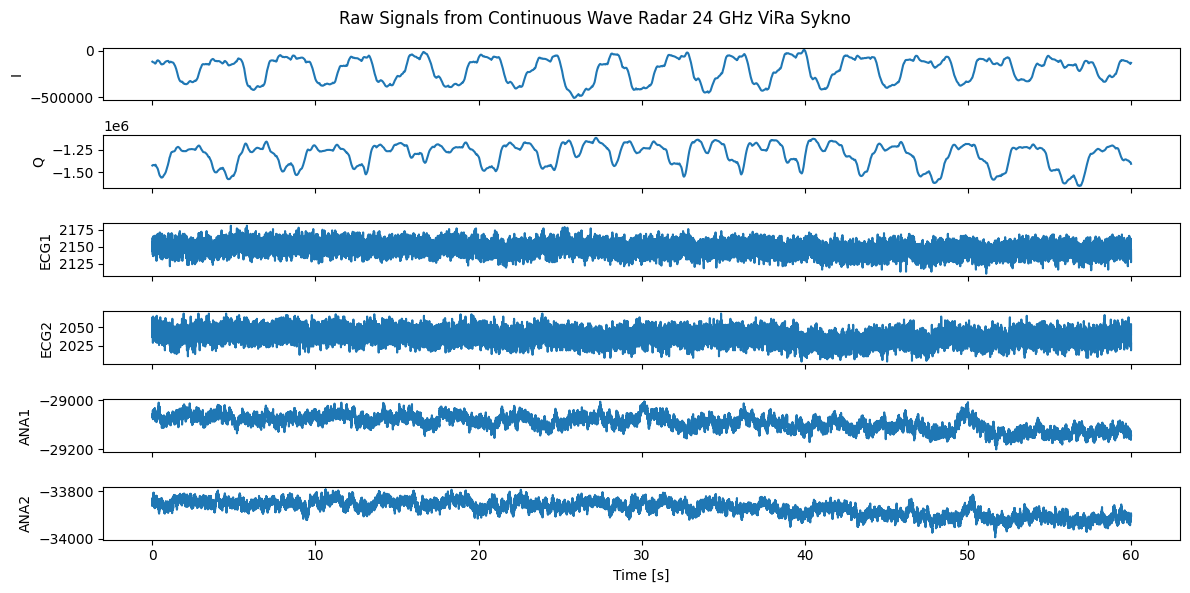

In [18]:
channels=['I', 'Q','ECG1','ECG2','ANA1', 'ANA2']  
# List of channel names
fig,axes=plt.subplots(len(channels),1,sharex=True) 
for ax,col in zip(axes,channels): 
    ax.plot(df['time'],df[col]) 
    ax.set_ylabel(col) 
    ax.grid() 
    
    
axes[-1].set_xlabel('Time [s]') 
plt.suptitle('Raw Signals from Continuous Wave Radar 24 GHz ViRa Sykno') 
plt.tight_layout() 
plt.show()



In [19]:
from scipy.signal import butter, filtfilt ,find_peaks 
from sklearn.metrics import mean_squared_error,mean_absolute_error 

from sklearn.preprocessing import MinMaxScaler,StandardScaler 
from sklearn.neural_network import MLPRegressor

fs=1000 
ecg=df['ECG1'].values.astype(np.float32)
ecg_norm=((ecg-ecg.mean())/ecg.std()+1e-8)

peaks, _ = find_peaks(ecg_norm, distance=fs*0.6, prominence=0.5)  # Find peaks with a minimum distance of 0.6 seconds and a prominence of 0.5
print(f"Number of detected peaks: {len(peaks)}")  # Print the number of detected peaks 
if len(peaks) > 0:
    print(f"Indices of detected peaks: {peaks}")  # Print the indices of detected peaks 
    rr=np.diff(peaks)/fs  # Calculate RR intervals in seconds
    hr=60/rr  # Calculate heart rate in beats per minute
    print(f"RR intervals (s): {rr}")  
    print(f"Heart rate (bpm): {hr}")



Number of detected peaks: 71
Indices of detected peaks: [  461  1080  1686  2372  3325  4211  4814  5798  6548  7398  8139  8969
  9867 10539 11209 12285 12923 13917 14701 15464 16637 17717 18654 19844
 21006 22191 22833 23979 24596 25278 26136 26877 27543 28204 28940 29660
 30269 31037 31917 32857 33944 34881 35726 36806 37527 38460 39308 40272
 40913 41846 42484 43158 44145 44858 45517 46412 47232 47893 48773 49857
 50563 51659 52285 53151 54144 55265 56052 57137 57835 58865 59892]
RR intervals (s): [0.619 0.606 0.686 0.953 0.886 0.603 0.984 0.75  0.85  0.741 0.83  0.898
 0.672 0.67  1.076 0.638 0.994 0.784 0.763 1.173 1.08  0.937 1.19  1.162
 1.185 0.642 1.146 0.617 0.682 0.858 0.741 0.666 0.661 0.736 0.72  0.609
 0.768 0.88  0.94  1.087 0.937 0.845 1.08  0.721 0.933 0.848 0.964 0.641
 0.933 0.638 0.674 0.987 0.713 0.659 0.895 0.82  0.661 0.88  1.084 0.706
 1.096 0.626 0.866 0.993 1.121 0.787 1.085 0.698 1.03  1.027]
Heart rate (bpm): [96.93053312 99.00990099 87.46355685 62.9590766 

In [24]:
I = df['I'].values.astype(np.float32) 
Q= df['Q'].values.astype(np.float32) 
## dc centering. 
I = I.mean()
Q = Q.mean()

window_sec= 4 
stride_sec= 1 

window_size = window_sec * fs  #
window_size = stride_sec * fs 

def extract_features(i_sig,q_sig): 
    amplitude = np.sqrt(i_sig**2 + q_sig**2)  # Calculate amplitude from I and Q signals
    phase = np.arctan2(q_sig, i_sig) 
    # Calculate phase from 
    phase_diff=np.diff(phase)
    features = {
        'amplitude_mean': np.mean(amplitude),  # Mean of amplitude
        'amplitude_std': np.std(amplitude),    # Standard deviation of amplitude
        'phase_mean': np.mean(phase),           # Mean of phase
        'phase_std': np.std(phase),             # Standard deviation of phase
        'phase_diff_mean': np.mean(phase_diff), # Mean of phase difference
        'phase_diff_std': np.std(phase_diff)    # Standard deviation of phase difference
    }
    return features

In [25]:
i_signal = df['I'].values.astype(np.float32)
q_signal = df['Q'].values.astype(np.float32)

# Remove DC offset before windowing.
i_signal = i_signal - np.mean(i_signal)
q_signal = q_signal - np.mean(q_signal)

window_sec = 4
stride_sec = 1

window_size = window_sec * fs
stride_size = stride_sec * fs

x = []
y = []
for start in range(0, len(i_signal) - window_size, stride_size):
    end = start + window_size
    i_window = i_signal[start:end]
    q_window = q_signal[start:end]
    p = peaks[(peaks >= start) & (peaks < end)] - start
    if len(p) >= 2:
        rr = np.diff(p) / fs
        window_hr = np.median(60 / rr)
        if 40 < window_hr < 180:
            features = extract_features(i_window, q_window)
            x.append(list(features.values()))
            y.append(window_hr)

x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

(57, 6)
(57,)


In [26]:
N=len(x)
train_end = int(0.8 * N)
val_end = int(0.9 * N) 
x_train=x[:train_end]
y_train=y[:train_end] 
x_val=x[train_end:val_end] 
y_val=y[train_end:val_end] 
x_test=x[val_end:] 
y_test=y[val_end:] 
print(f"Training set: {x_train.shape}, {y_train.shape}")
print(f"Validation set: {x_val.shape}, {y_val.shape}")
print(f"Test set: {x_test.shape}, {y_test.shape}")


Training set: (45, 6), (45,)
Validation set: (6, 6), (6,)
Test set: (6, 6), (6,)


In [27]:
scaler = StandardScaler() 
x_train_n=scaler.fit_transform(x_train)
x_val_n=scaler.transform(x_val) 
x_test_n=scaler.transform(x_test)
print(scaler.mean_)
print(scaler.scale_)

[ 1.69702860e+05  4.58419588e+04  1.01043594e+00  1.44378108e+00
 -4.03877992e-06  1.65911672e-02]
[1.63516947e+04 9.57764659e+03 2.84819272e-01 1.50286610e-01
 3.59113723e-04 3.85798438e-02]


In [29]:
model=MLPRegressor(
    hidden_layer_sizes=(4,),activation='relu',solver='adam',max_iter=5000,
    learning_rate_init=0.001,random_state=42
    ,validation_fraction=0.2
)
model.fit(x_train_n,y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(4,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,5000
,shuffle,True


In [30]:
pred=model.predict(x_test_n) 
mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))
print(f"Mean Absolute Error (MAE): {mae:.2f} bpm")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} bpm")
for true, predicted in zip(y_test, pred):
    print(f"True: {true:.2f} bpm, Predicted: {predicted:.2f} bpm")

Mean Absolute Error (MAE): 28.04 bpm
Root Mean Squared Error (RMSE): 38.90 bpm
True: 69.28 bpm, Predicted: 71.37 bpm
True: 60.42 bpm, Predicted: 65.62 bpm
True: 60.42 bpm, Predicted: 136.48 bpm
True: 65.77 bpm, Predicted: 84.43 bpm
True: 67.25 bpm, Predicted: 15.12 bpm
True: 58.34 bpm, Predicted: 72.42 bpm


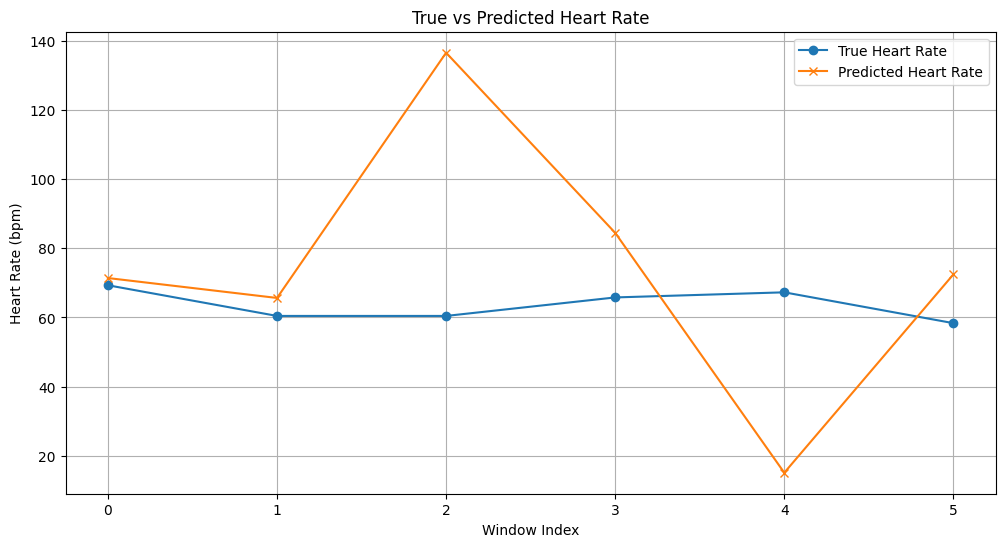

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='True Heart Rate', marker='o')
plt.plot(pred, label='Predicted Heart Rate', marker='x')
plt.title('True vs Predicted Heart Rate')
plt.xlabel('Window Index')
plt.ylabel('Heart Rate (bpm)')
plt.legend()
plt.show()

In [33]:
w1 = model.coefs_[0]
b1 = model.intercepts_[0]
w2 = model.coefs_[1]
b2 = model.intercepts_[1]
print(w1.shape)
print(w2.shape)

print(b1.shape)
print(b2.shape)

(6, 4)
(4, 1)
(4,)
(1,)


In [34]:
max_w = max(np.max(np.abs(w1)), np.max(np.abs(w2))) 
weight_scale=max_w/127 
w1_q=np.round(w1/weight_scale).astype(np.int8)
w2_q=np.round(w2/weight_scale).astype(np.int8)
print(f"Weight scale: {weight_scale:.6f}") 
print(f"Quantized weights for layer 1: {w1_q}") 
print(f"Quantized weights for layer 2: {w2_q}") 

Weight scale: 0.048922
Quantized weights for layer 1: [[-107    0  127    0]
 [   1   -1  -35   11]
 [ -30   -1  -16    6]
 [  27    0  -54   -1]
 [ -37    0  -79    0]
 [ -87    0  -63   -5]]
Quantized weights for layer 2: [[100]
 [-14]
 [ 93]
 [ -9]]
